# Majors Markout Study — Findings & EDA
### BTC · ETH · SOL · HYPE · SPX — Aug 2025 – Jun 2026 (11 months)

**Question.** For the liquid markets we could actually copy at size, do takers have a
*profitable exit window* — an entry that is informed and a horizon at which the drift is still
positive — so we could copy on entry and optimize the exit?

**Method (one line).** From the complete `cand2` fill tape we reconstruct every taker's
*opening* decisions (maker/wash fills excluded; burn-in discards pre-window inventory), price
them **post-fill** (close of the first 5-min bar *after* the fill), and measure the signed
**markout** at 12 horizons (5m → 168h). We winsorize the magnitude at the p99 of each
(coin,horizon), report deployable **volume-weighted** edge net of a modeled round-trip cost
(an **upper bound on net edge** — top-of-book cost only, no market impact at copy size; the
half-spread is a **placeholder pending BBO calibration**), and — for the candidate list — pick
each wallet's exit horizon on a **train time-half** and score it on a **held-out** half with a
moving-block bootstrap.

> **Read this first — what these numbers are and are NOT.**
> This is a **descriptive, in-sample** study. It characterises each wallet's historical record;
> it is **not** an out-of-sample edge claim. In this project, in-sample edge has repeatedly
> failed to persist and even inverted. The "stable candidate" list below is a *candidate
> generator*, not a set of confirmed informed traders — the decisive test is the phase-2
> **future-window** out-of-sample pass. The winner's-curse figure at the end shows exactly why
> that discipline is required. Built by code that passed two architecture-audit rounds and one
> code-audit round; every number traces to `cand2_*` + `bars_*`.

In [1]:
import sys; sys.path.insert(0, ".")
%matplotlib inline
import polars as pl
import eda_figs as F   # figure library (also writes PNGs to ../out/figs/)
OUT = F.OUT

## 1. Scope & data quality
How much evidence stands behind each market, and is the pricing honest at every horizon
(coverage = fraction of entries that have a priceable exit bar; near-100% means no
survivorship from delisting/gaps).

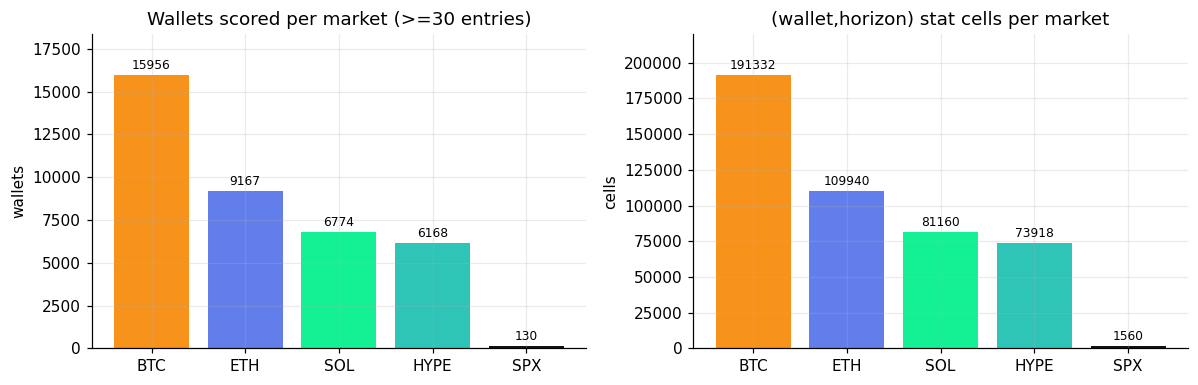

In [2]:
F.fig_scope()

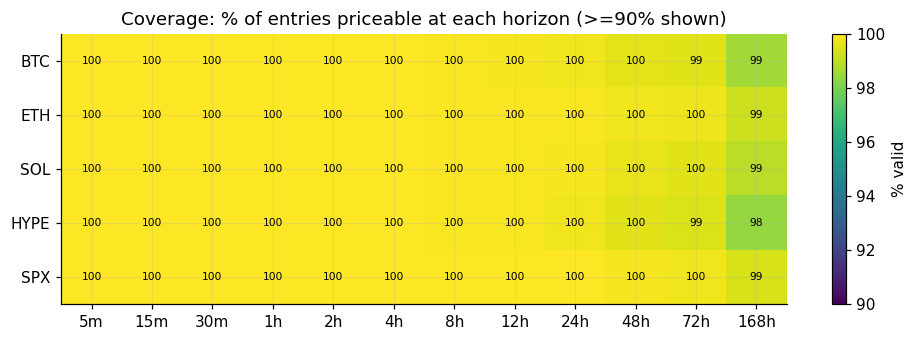

In [3]:
F.fig_coverage()

## 2. The centerpiece — field markout term structure
Mean signed markout (bps) of the **average taker** in each market, by holding horizon. This is
the baseline every individual wallet is read against, and it answers the exit-window question
at the market level.

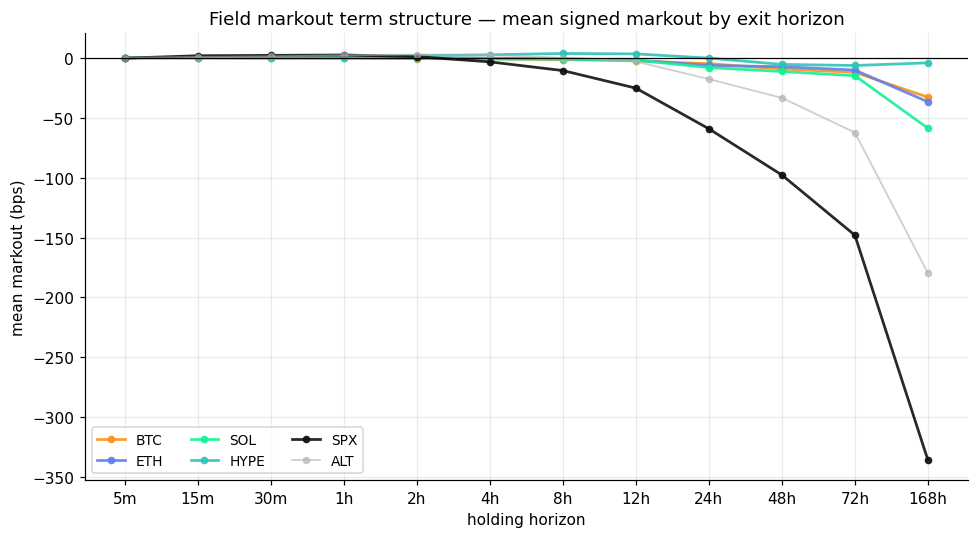

In [4]:
F.fig_term_structure()

**BTC and SOL bleed monotonically**; ETH is flat-to-slightly-positive near zero (a trivial
+0.07 bp blip at 1h) before bleeding — the average taker in the deep majors loses more the
longer they hold (adverse selection). **HYPE, SPX and ALT show a positive short-horizon drift
window** that peaks then reverses (HYPE ~+3.5 bp at 8h; SPX 1–2h; ALT 1–4h).

> **Critical caveat.** These field drifts are only *single-digit bps* — **below the 8–14 bp
> round-trip cost** (§6). So at the **field level the window is NOT copyable**: cost eats it.
> Any copyable edge would have to come from a wallet *subset* that beats both the field and the
> cost — and §7 shows most such in-sample subsets fail out-of-window.

In the full-range plot above, the majors compress near zero because SPX/ALT collapse to −180 to
−335 bp by 168h — read it *with* the zoom below, not alone.

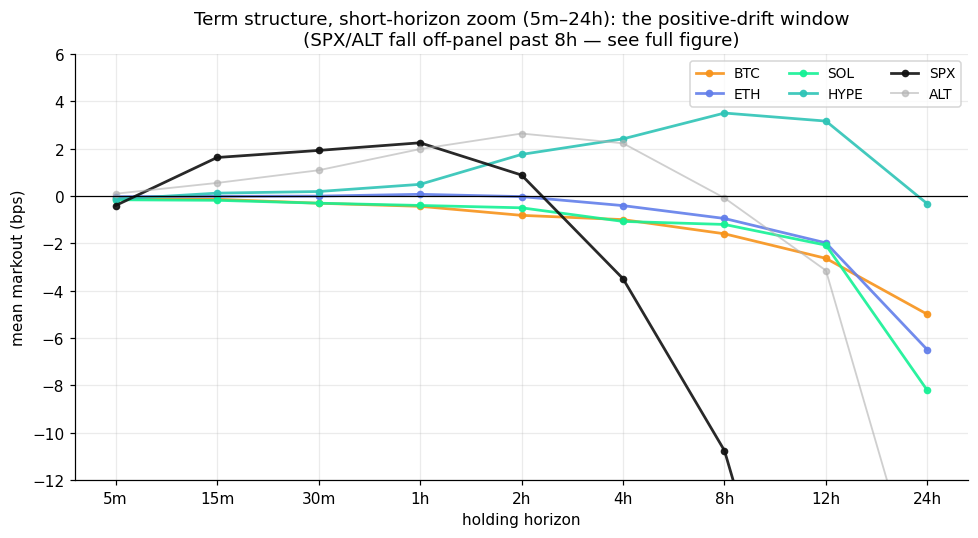

In [5]:
F.fig_term_structure_zoom()

In [6]:
# the numbers behind the centerpiece
f = pl.read_parquet(OUT/'field_by_coin_horizon.parquet')
H = ['5m','15m','30m','1h','2h','4h','8h','12h','24h','48h','72h','168h']
piv = f.filter(pl.col('coin').is_in(['BTC','ETH','SOL','HYPE','SPX','ALT'])).pivot(values='field_mean_bps', index='coin', on='horizon')
piv.select(['coin']+[h for h in H if h in piv.columns]).with_columns([pl.col(h).round(1) for h in H if h in piv.columns])

coin,5m,15m,30m,1h,2h,4h,8h,12h,24h,48h,72h,168h
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""ALT""",0.1,0.6,1.1,2.0,2.6,2.2,-0.1,-3.1,-17.9,-33.5,-62.4,-179.6
"""BTC""",-0.1,-0.1,-0.3,-0.4,-0.8,-1.0,-1.6,-2.6,-5.0,-9.4,-12.2,-33.0
"""ETH""",-0.0,-0.0,-0.0,0.1,-0.0,-0.4,-0.9,-2.0,-6.5,-7.5,-10.3,-36.8
"""HYPE""",-0.1,0.1,0.2,0.5,1.8,2.4,3.5,3.2,-0.3,-5.6,-6.5,-4.3
"""SOL""",-0.2,-0.2,-0.3,-0.4,-0.5,-1.1,-1.2,-2.1,-8.2,-11.5,-15.0,-58.8
"""SPX""",-0.4,1.6,1.9,2.2,0.9,-3.5,-10.8,-25.4,-59.3,-97.8,-148.1,-335.5


## 3. Winsorization & risk term structure
Left: the p99-magnitude winsorization vs the raw field mean — it tames the fat long-horizon
tail (which flat-clipping distorted asymmetrically) without moving the short-horizon signal.
Right: downside deviation grows sharply with horizon — the risk cost of holding.

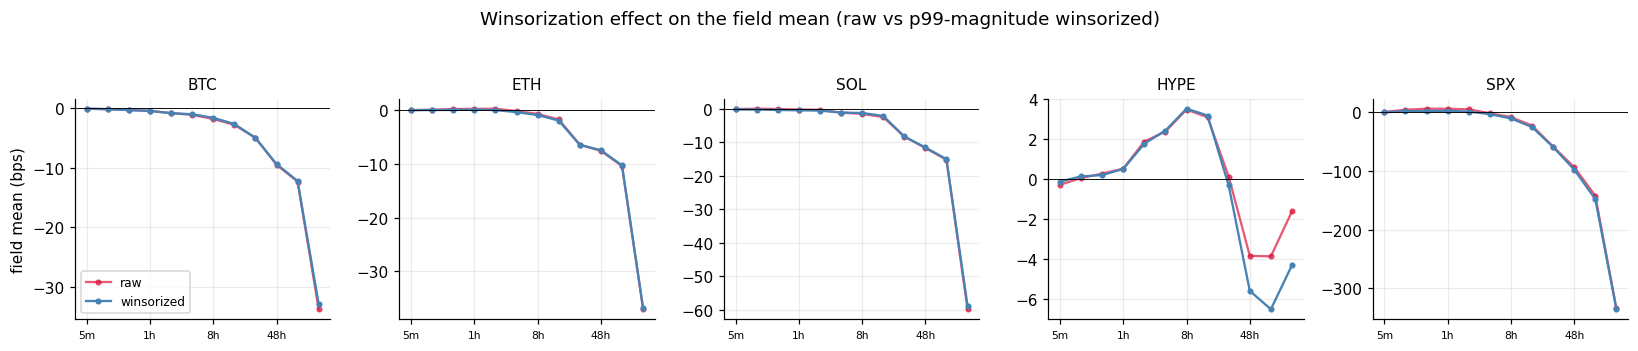

In [7]:
F.fig_winsor_effect()

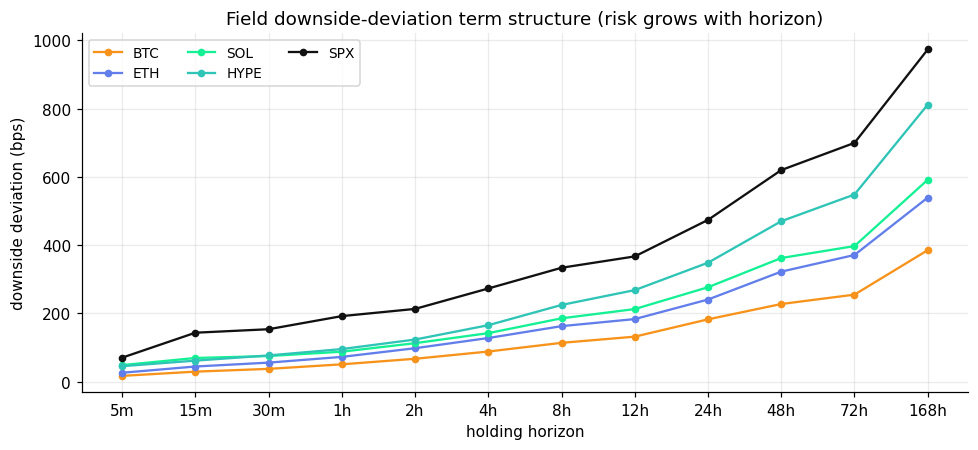

In [8]:
F.fig_downside_term()

## 4. Directionality — long vs short
Whether the taker edge is symmetric or lives on one side (e.g. dip-buying vs rip-selling).

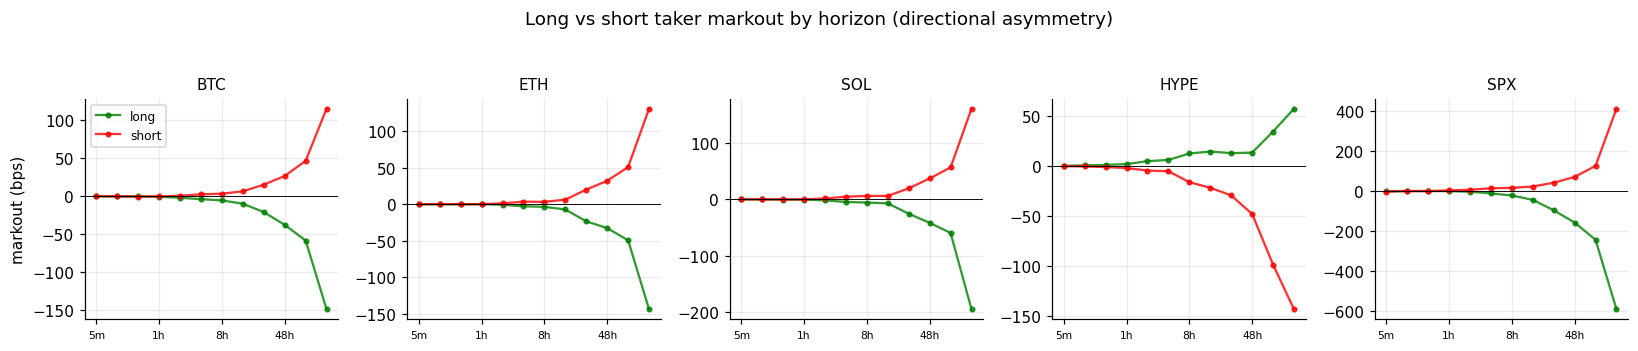

In [9]:
F.fig_long_short()

## 5. Per-wallet dispersion & the capacity lesson
The field mean is small, but wallets vary enormously. The key discipline: an edge that shows
up **equal-weighted** (size-blind) but not **volume-weighted** (deployable) cannot be funded —
it lives in trades too small to absorb capital. The scatter shows how far the two diverge.

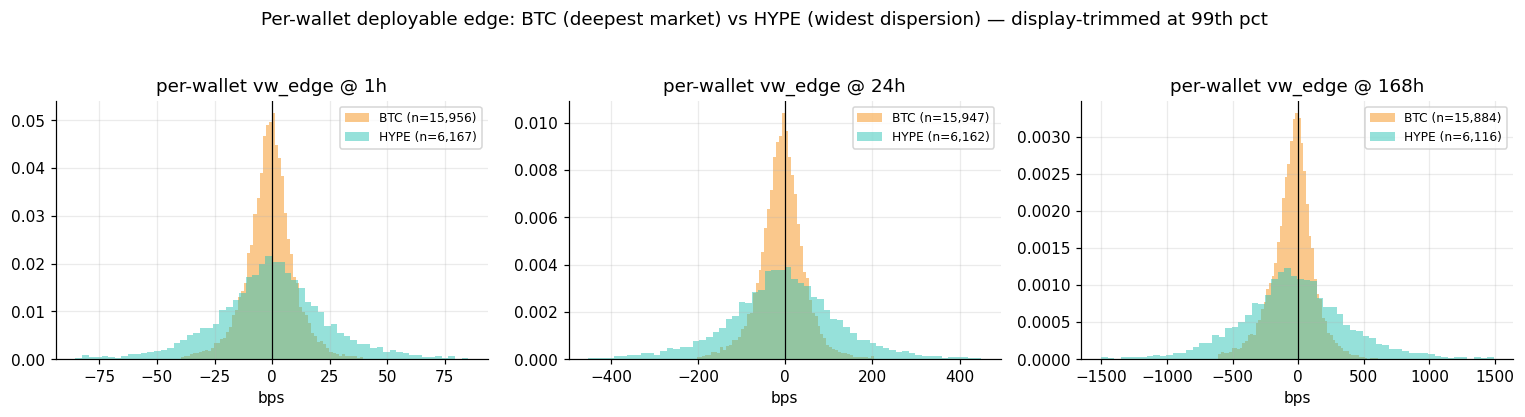

In [10]:
F.fig_edge_dist()

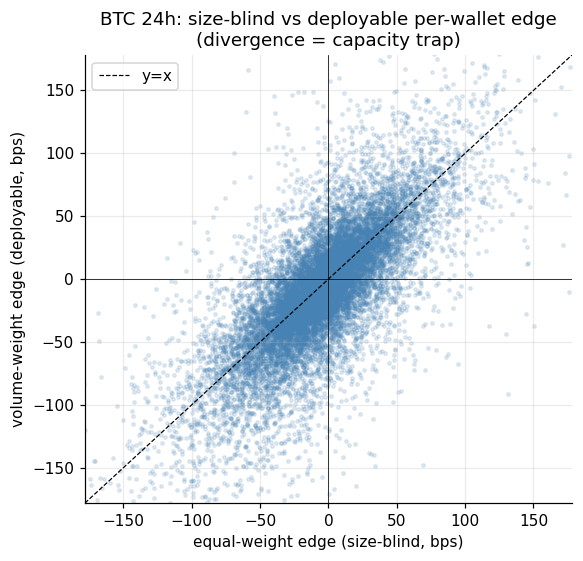

In [11]:
F.fig_size_blind_vs_deployable()

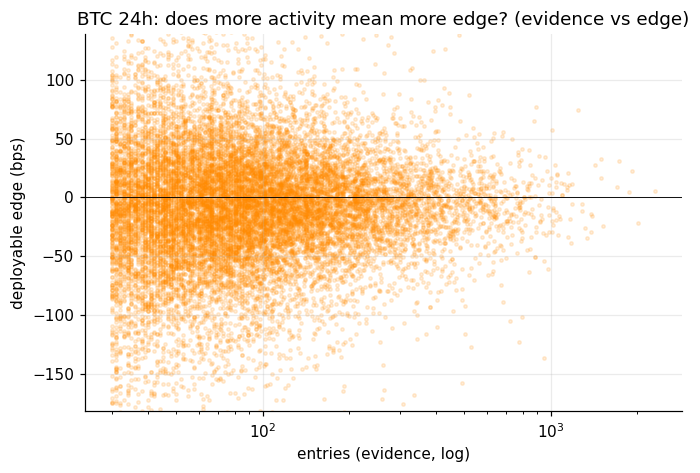

In [12]:
F.fig_n_vs_edge()

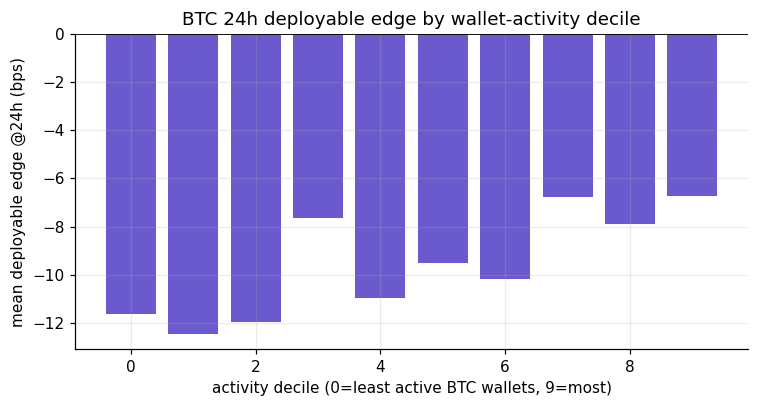

In [13]:
F.fig_activity_decile()

## 6. The deliverable — optimal-exit roll-up
For each (wallet, coin): the exit horizon that maximises the deployable curve on a **train
half**, its **held-out** peak net-of-cost, and a **stability** flag (block-bootstrap lower CI
> 0 **and** beats the field). The funnel shows how few survive; `h_star` shows where the
(in-sample) optimal exits land; the gate scatter shows the lower-CI filter.

*The `med_peak_net_bps` column below (136–809 bps) is the **post-selection positive tail**, and
most stable candidates' `h_star` sits at 168h — the ladder ceiling, i.e. the markout was still
climbing when our window ended, not a found exit. §7 shows most such in-sample peaks do not
survive out-of-window. Read these as **leads, not edges.***

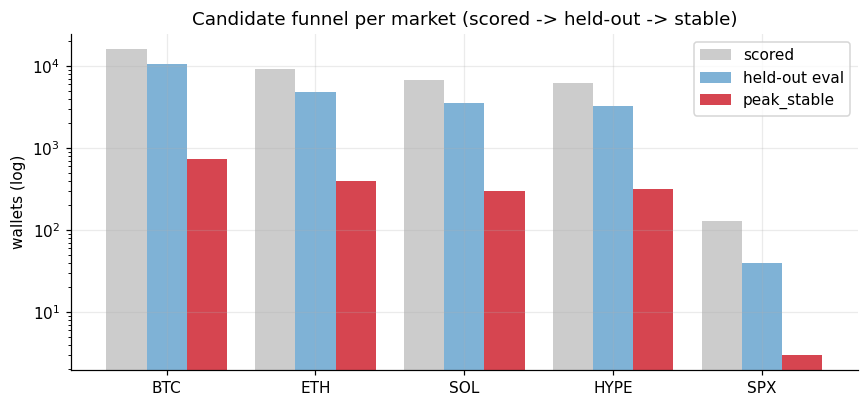

In [14]:
F.fig_stable_counts()

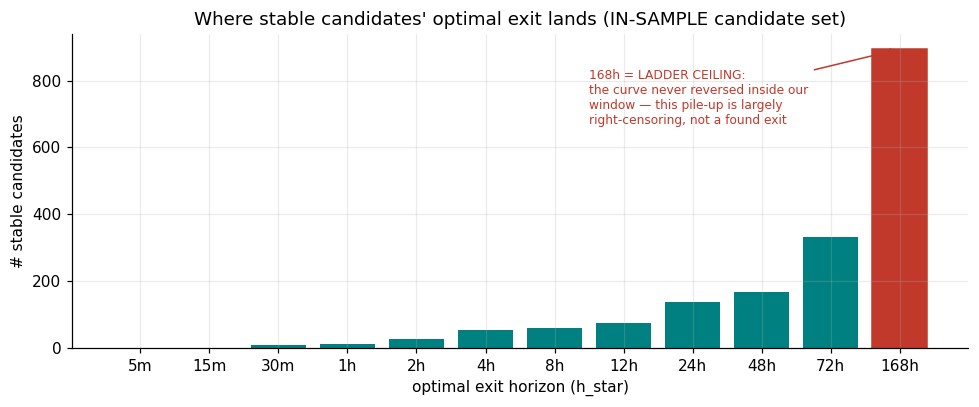

In [15]:
F.fig_hstar_dist()

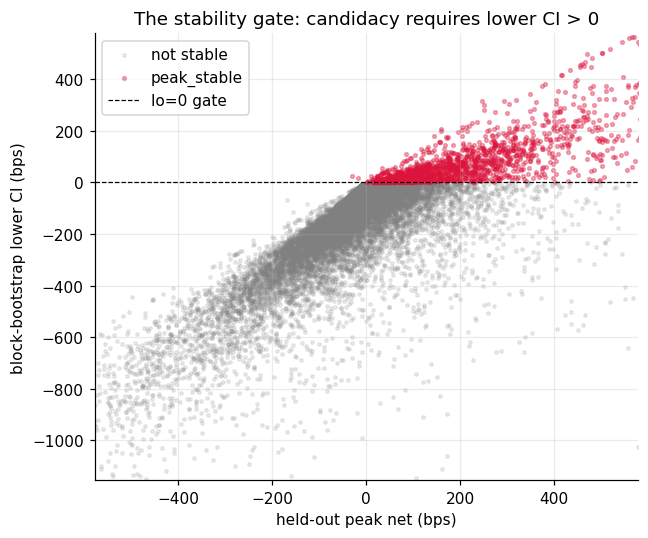

In [16]:
F.fig_peak_vs_lo()

In [17]:
o = pl.read_parquet(OUT/'optimal_exit.parquet')
o.group_by('coin').agg(scored=pl.len(),
    held_out=(pl.col('peak_net_bps').is_not_null()).sum(),
    stable=pl.col('peak_stable').sum(),
    med_peak_net_bps=pl.col('peak_net_bps').filter(pl.col('peak_stable')).median().round(0)).sort('coin')

coin,scored,held_out,stable,med_peak_net_bps
str,u32,u32,u32,f64
"""BTC""",15877,10557,744,136.0
"""ETH""",9128,4854,396,200.0
"""HYPE""",6109,3269,320,401.0
"""SOL""",6703,3510,302,214.0
"""SPX""",130,40,3,809.0


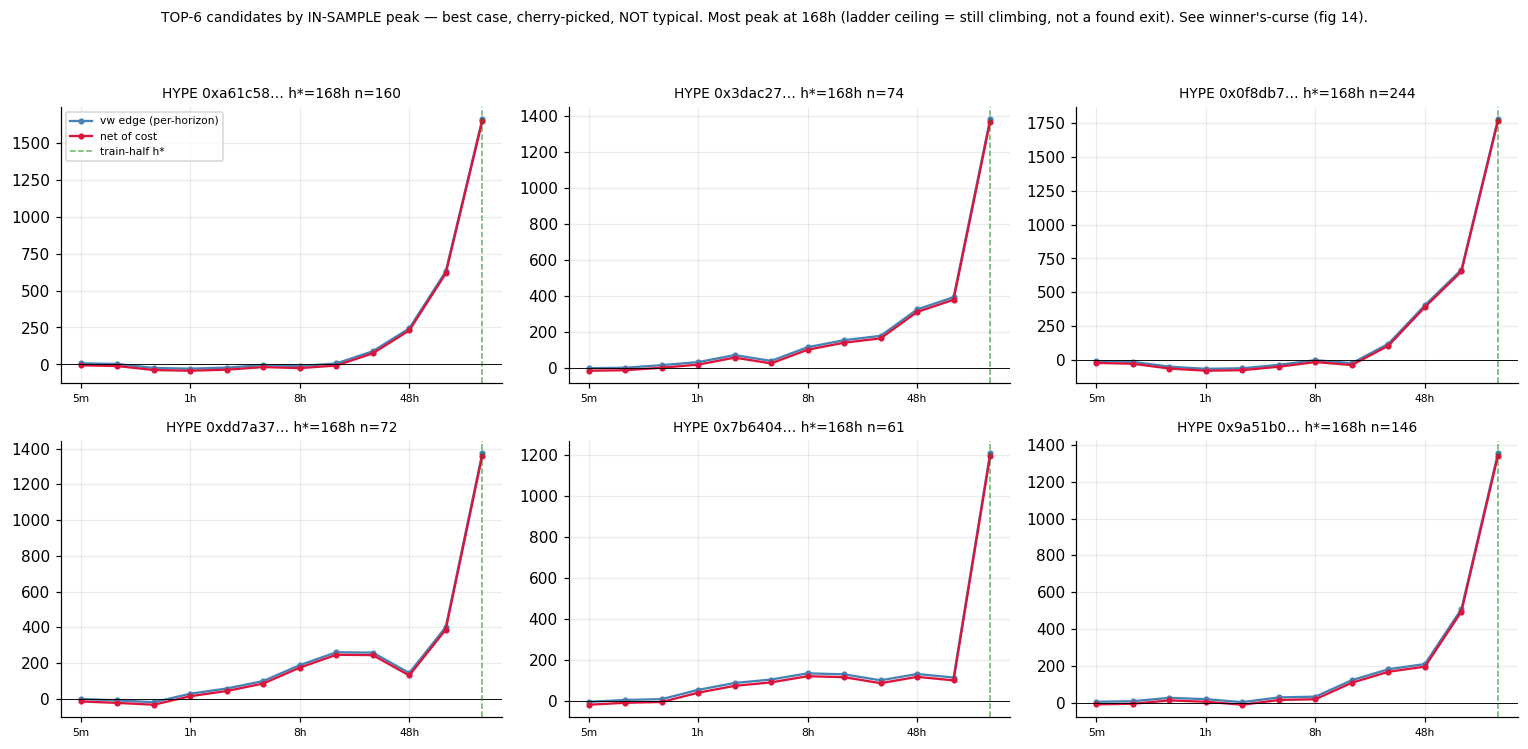

In [18]:
F.fig_example_candidates()

## 7. The honest test — winner's curse
Each point is a wallet: its **in-sample** train-half peak (x) vs the **held-out** value at that
same horizon (y). If in-sample peaks were real skill, points would track y=x. Instead the
**binned mean sits at or below zero and even declines** as the in-sample peak rises — the
highest in-sample peaks regress *fully past* the mean out of (this-window) sample. Reality is
*worse* than "no edge": held-out means run −11 to −48 bp net across the range.

**Implication.** The bulk of the apparent edge is selection noise. The held-out gate removes the
worst of it, but with thousands of wallets tested some pass by chance. Whether *any* of the
~1,765 stable candidates are genuinely informed can only be settled by the **phase-2 test**:
rank on the first N months and measure on a held-out **future** month. Until then, treat the
candidate list as leads, not conclusions.

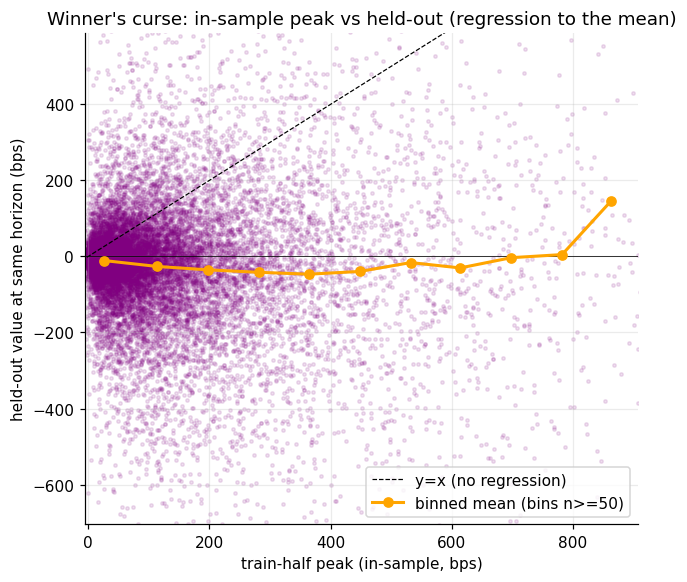

In [19]:
F.fig_winnerscurse()

## Summary
- **Where a positive drift window exists** (but is **NOT field-level copyable — the drift is
  below the 8–14bp round-trip cost**): the **short horizons of HYPE / SPX / alts** (HYPE ~+3.5bp
  at 8h; SPX 1–2h; ALT 1–4h). In BTC/SOL even the drift is absent (monotonic bleed); ETH is flat.
- **Deployability discipline:** all headline edges are volume-weighted and net of a modeled
  round-trip cost; the size-blind vs deployable gap is shown explicitly.
- **Candidate list:** ~1,765 wallets clear an in-sample held-out, cost-netted, bootstrap-stable
  bar — **candidates, not confirmed alpha.**
- **Next:** phase-2 future-window OOS test to see whether any survive. The winner's-curse figure
  is the reason that test is non-negotiable.

*Artifacts: `out/markout_stats.parquet`, `out/field_by_coin_horizon.parquet`,
`out/coverage_report.parquet`, `out/optimal_exit.parquet`, `out/winsor_caps.parquet`;
figures in `out/figs/`. Regenerate: `python eda_figs.py`.*